In [1]:
!pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install --upgrade pip setuptools wheel
!pip install catboost --no-cache-dir


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 3.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: setuptools
    Found existing installation: setuptools 79.0.0
    Uninstalling setuptools-79.0.0:
      Successfully uninstalled setuptools-79.0.0
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder


In [4]:
df=pd.read_csv('car.csv')

In [5]:
df.head(5)

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Road_surface_conditions,Light_conditions,Weather_conditions,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,1-2yr,Automobile,Residential areas,Dry,Daylight,Normal,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Above 10yr,Public (> 45 seats),Office areas,Dry,Daylight,Normal,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,1-2yr,Lorry (41?100Q),Recreational areas,Dry,Daylight,Normal,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,5-10yr,Public (> 45 seats),Office areas,Dry,Darkness - lights lit,Normal,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,2-5yr,NaN,Industrial areas,Dry,Darkness - lights lit,Normal,Overtaking,Slight Injury


In [6]:
df.shape

(12316, 12)

In [7]:
df.isnull().sum()

Time                         0
Day_of_week                  0
Age_band_of_driver           0
Sex_of_driver                0
Driving_experience         829
Type_of_vehicle            950
Area_accident_occured      239
Road_surface_conditions      0
Light_conditions             0
Weather_conditions           0
Cause_of_accident            0
Accident_severity            0
dtype: int64

In [8]:
df.describe()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Road_surface_conditions,Light_conditions,Weather_conditions,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,11487,11366,12077,12316,12316,12316,12316,12316
unique,1074,7,5,3,7,17,14,4,4,9,20,3
top,15:30:00,Friday,18-30,Male,5-10yr,Automobile,Other,Dry,Daylight,Normal,No distancing,Slight Injury
freq,120,2041,4271,11437,3363,3205,3819,9340,8798,10063,2263,10415


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Time                     12316 non-null  object
 1   Day_of_week              12316 non-null  object
 2   Age_band_of_driver       12316 non-null  object
 3   Sex_of_driver            12316 non-null  object
 4   Driving_experience       11487 non-null  object
 5   Type_of_vehicle          11366 non-null  object
 6   Area_accident_occured    12077 non-null  object
 7   Road_surface_conditions  12316 non-null  object
 8   Light_conditions         12316 non-null  object
 9   Weather_conditions       12316 non-null  object
 10  Cause_of_accident        12316 non-null  object
 11  Accident_severity        12316 non-null  object
dtypes: object(12)
memory usage: 1.1+ MB


In [10]:
df.dropna(subset=['Driving_experience','Type_of_vehicle','Area_accident_occured'],inplace=True)

In [11]:
df.isnull().sum()

Time                       0
Day_of_week                0
Age_band_of_driver         0
Sex_of_driver              0
Driving_experience         0
Type_of_vehicle            0
Area_accident_occured      0
Road_surface_conditions    0
Light_conditions           0
Weather_conditions         0
Cause_of_accident          0
Accident_severity          0
dtype: int64

In [12]:
duplicates=df[df.duplicated()]

In [13]:
df.drop(df[df.eq('Unknown').any(axis=1)].index, inplace=True)

In [14]:
# One-Hot Encoding 
df = pd.get_dummies(df, columns=['Sex_of_driver'])

In [15]:
df.head(5)

,Time,Day_of_week,Age_band_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Road_surface_conditions,Light_conditions,Weather_conditions,Cause_of_accident,Accident_severity,Sex_of_driver_Female,Sex_of_driver_Male
0,17:02:00,Monday,18-30,1-2yr,Automobile,Residential areas,Dry,Daylight,Normal,Moving Backward,Slight Injury,False,True
1,17:02:00,Monday,31-50,Above 10yr,Public (> 45 seats),Office areas,Dry,Daylight,Normal,Overtaking,Slight Injury,False,True
2,17:02:00,Monday,18-30,1-2yr,Lorry (41?100Q),Recreational areas,Dry,Daylight,Normal,Changing lane to the left,Serious Injury,False,True
3,1:06:00,Sunday,18-30,5-10yr,Public (> 45 seats),Office areas,Dry,Darkness - lights lit,Normal,Changing lane to the right,Slight Injury,False,True
6,17:30:00,Wednesday,18-30,2-5yr,Automobile,Residential areas,Dry,Daylight,Normal,Other,Slight Injury,False,True


In [16]:
# One-Hot Encoding
df = pd.get_dummies(df, columns=['Light_conditions'])

In [17]:
df.head(5)

,Time,Day_of_week,Age_band_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Road_surface_conditions,Weather_conditions,Cause_of_accident,Accident_severity,Sex_of_driver_Female,Sex_of_driver_Male,Light_conditions_Darkness - lights lit,Light_conditions_Darkness - lights unlit,Light_conditions_Darkness - no lighting,Light_conditions_Daylight
0,17:02:00,Monday,18-30,1-2yr,Automobile,Residential areas,Dry,Normal,Moving Backward,Slight Injury,False,True,False,False,False,True
1,17:02:00,Monday,31-50,Above 10yr,Public (> 45 seats),Office areas,Dry,Normal,Overtaking,Slight Injury,False,True,False,False,False,True
2,17:02:00,Monday,18-30,1-2yr,Lorry (41?100Q),Recreational areas,Dry,Normal,Changing lane to the left,Serious Injury,False,True,False,False,False,True
3,1:06:00,Sunday,18-30,5-10yr,Public (> 45 seats),Office areas,Dry,Normal,Changing lane to the right,Slight Injury,False,True,True,False,False,False
6,17:30:00,Wednesday,18-30,2-5yr,Automobile,Residential areas,Dry,Normal,Other,Slight Injury,False,True,False,False,False,True


In [18]:
#One-Hot Encoding
df = pd.get_dummies(df, columns=['Road_surface_conditions'])

In [19]:
df.head(5)

,Time,Day_of_week,Age_band_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Weather_conditions,Cause_of_accident,Accident_severity,Sex_of_driver_Female,Sex_of_driver_Male,Light_conditions_Darkness - lights lit,Light_conditions_Darkness - lights unlit,Light_conditions_Darkness - no lighting,Light_conditions_Daylight,Road_surface_conditions_Dry,Road_surface_conditions_Flood over 3cm. deep,Road_surface_conditions_Snow,Road_surface_conditions_Wet or damp
0,17:02:00,Monday,18-30,1-2yr,Automobile,Residential areas,Normal,Moving Backward,Slight Injury,False,True,False,False,False,True,True,False,False,False
1,17:02:00,Monday,31-50,Above 10yr,Public (> 45 seats),Office areas,Normal,Overtaking,Slight Injury,False,True,False,False,False,True,True,False,False,False
2,17:02:00,Monday,18-30,1-2yr,Lorry (41?100Q),Recreational areas,Normal,Changing lane to the left,Serious Injury,False,True,False,False,False,True,True,False,False,False
3,1:06:00,Sunday,18-30,5-10yr,Public (> 45 seats),Office areas,Normal,Changing lane to the right,Slight Injury,False,True,True,False,False,False,True,False,False,False
6,17:30:00,Wednesday,18-30,2-5yr,Automobile,Residential areas,Normal,Other,Slight Injury,False,True,False,False,False,True,True,False,False,False


In [20]:
df.head(10)

,Time,Day_of_week,Age_band_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Weather_conditions,Cause_of_accident,Accident_severity,Sex_of_driver_Female,Sex_of_driver_Male,Light_conditions_Darkness - lights lit,Light_conditions_Darkness - lights unlit,Light_conditions_Darkness - no lighting,Light_conditions_Daylight,Road_surface_conditions_Dry,Road_surface_conditions_Flood over 3cm. deep,Road_surface_conditions_Snow,Road_surface_conditions_Wet or damp
0,17:02:00,Monday,18-30,1-2yr,Automobile,Residential areas,Normal,Moving Backward,Slight Injury,False,True,False,False,False,True,True,False,False,False
1,17:02:00,Monday,31-50,Above 10yr,Public (> 45 seats),Office areas,Normal,Overtaking,Slight Injury,False,True,False,False,False,True,True,False,False,False
2,17:02:00,Monday,18-30,1-2yr,Lorry (41?100Q),Recreational areas,Normal,Changing lane to the left,Serious Injury,False,True,False,False,False,True,True,False,False,False
3,1:06:00,Sunday,18-30,5-10yr,Public (> 45 seats),Office areas,Normal,Changing lane to the right,Slight Injury,False,True,True,False,False,False,True,False,False,False
6,17:30:00,Wednesday,18-30,2-5yr,Automobile,Residential areas,Normal,Other,Slight Injury,False,True,False,False,False,True,True,False,False,False
7,17:20:00,Friday,18-30,2-5yr,Automobile,Residential areas,Normal,No priority to vehicle,Slight Injury,False,True,False,False,False,True,True,False,False,False
8,17:20:00,Friday,18-30,Above 10yr,Lorry (41?100Q),Industrial areas,Normal,Changing lane to the right,Slight Injury,False,True,False,False,False,True,True,False,False,False
9,17:20:00,Friday,18-30,1-2yr,Automobile,Residential areas,Normal,Moving Backward,Serious Injury,False,True,False,False,False,True,True,False,False,False
10,14:40:00,Saturday,18-30,1-2yr,Public (13?45 seats),Residential areas,Normal,Changing lane to the left,Serious Injury,False,True,False,False,False,True,True,False,False,False
11,14:40:00,Saturday,31-50,No Licence,Automobile,Office areas,Normal,No priority to pedestrian,Serious Injury,False,True,False,False,False,True,True,False,False,False


/var/folders/9x/hpz81btn0rg3wpby02mrn3lc0000gn/T/ipykernel_20048/1375781217.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Accident_severity", palette="Set1")


Text(0, 0.5, 'Count')

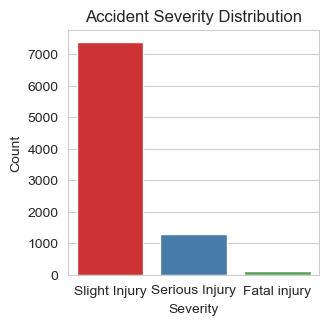

In [21]:
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(11,7))
plt.subplot(2, 3, 1)
sns.countplot(data=df, x="Accident_severity", palette="Set1")
plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")


/var/folders/9x/hpz81btn0rg3wpby02mrn3lc0000gn/T/ipykernel_20048/4130900188.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Day_of_week", order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], palette="Blues")


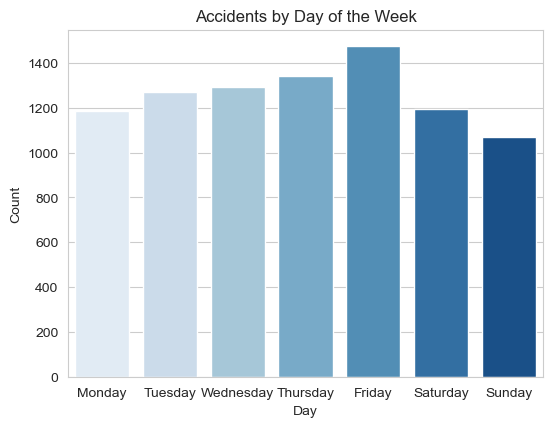

In [22]:
# 5. Time Analysis: Accidents by Day of the Week
plt.figure(figsize=(16,8))
sns.set_style("whitegrid")
plt.subplot(2, 3, 5)
sns.countplot(data=df, x="Day_of_week", order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], palette="Blues")
plt.title("Accidents by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


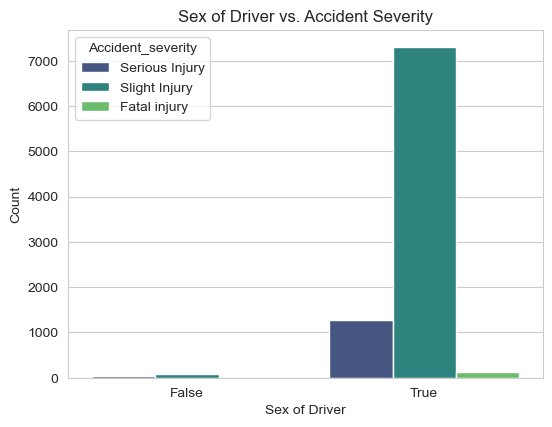

In [23]:
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")
plt.subplot(2, 3, 3)


sns.countplot(data=df, x="Sex_of_driver_Male", hue="Accident_severity", palette="viridis")

plt.title("Sex of Driver vs. Accident Severity")
plt.xlabel("Sex of Driver")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


/var/folders/9x/hpz81btn0rg3wpby02mrn3lc0000gn/T/ipykernel_20048/3678826404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Type_of_vehicle", order=df["Type_of_vehicle"].value_counts().index, palette="coolwarm")


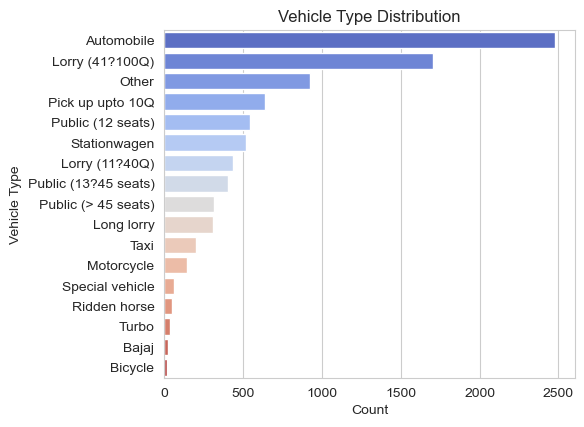

In [24]:
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")
plt.subplot(2, 3, 2)
sns.countplot(data=df, y="Type_of_vehicle", order=df["Type_of_vehicle"].value_counts().index, palette="coolwarm")
plt.title("Vehicle Type Distribution")
plt.xlabel("Count")
plt.ylabel("Vehicle Type")
plt.tight_layout()
plt.show()


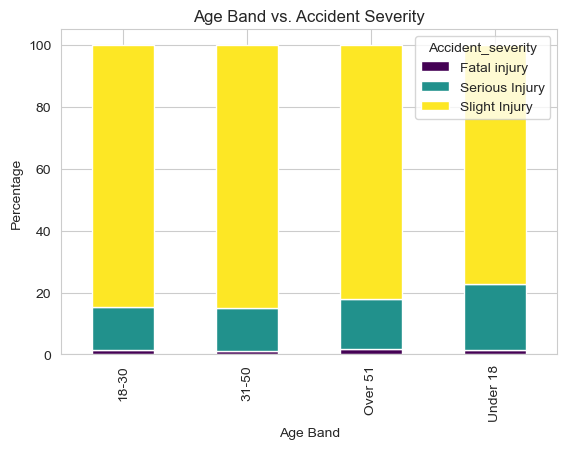

In [25]:
plt.figure(figsize=(16,8))
sns.set_style("whitegrid")
plt.subplot(2, 3, 4)
age_severity = pd.crosstab(df["Age_band_of_driver"], df["Accident_severity"], normalize="index") * 100
age_severity.plot(kind="bar", stacked=True, colormap="viridis", ax=plt.gca())
plt.title("Age Band vs. Accident Severity")
plt.xlabel("Age Band")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()


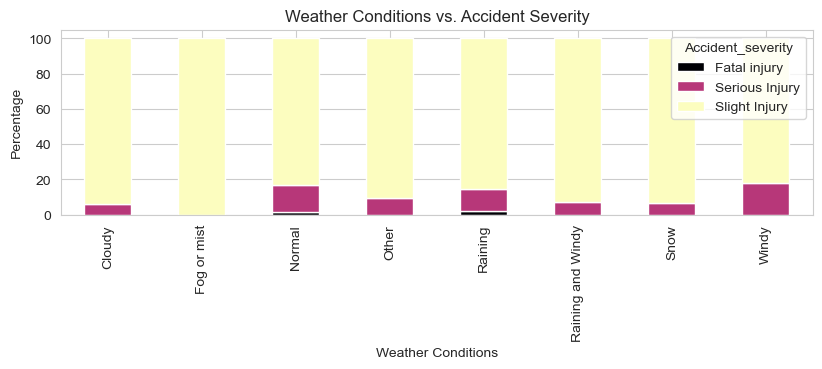

In [26]:
plt.figure(figsize=(16,8))
sns.set_style("whitegrid")
plt.subplot(3, 2, 6)
weather_severity = pd.crosstab(df["Weather_conditions"], df["Accident_severity"], normalize="index") * 100
weather_severity.plot(kind="bar", stacked=True, colormap="magma", ax=plt.gca())
plt.title("Weather Conditions vs. Accident Severity")
plt.xlabel("Weather Conditions")
plt.ylabel("Percentage")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18]),
 [Text(0, 0, 'Changing lane to the left'),
  Text(1, 0, 'Changing lane to the right'),
  Text(2, 0, 'Driving at high speed'),
  Text(3, 0, 'Driving carelessly'),
  Text(4, 0, 'Driving to the left'),
  Text(5, 0, 'Driving under the influence of drugs'),
  Text(6, 0, 'Drunk driving'),
  Text(7, 0, 'Getting off the vehicle improperly'),
  Text(8, 0, 'Improper parking'),
  Text(9, 0, 'Moving Backward'),
  Text(10, 0, 'No distancing'),
  Text(11, 0, 'No priority to pedestrian'),
  Text(12, 0, 'No priority to vehicle'),
  Text(13, 0, 'Other'),
  Text(14, 0, 'Overloading'),
  Text(15, 0, 'Overspeed'),
  Text(16, 0, 'Overtaking'),
  Text(17, 0, 'Overturning'),
  Text(18, 0, 'Turnover')])

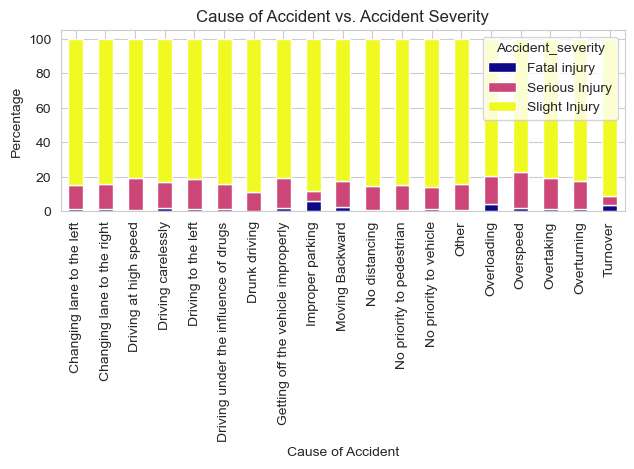

In [27]:
plt.figure(figsize=(16,8))
sns.set_style("whitegrid")
plt.subplot(3, 2, 5)
cause_severity = pd.crosstab(df["Cause_of_accident"], df["Accident_severity"], normalize="index") * 100
cause_severity.plot(kind="bar", stacked=True, colormap="plasma", ax=plt.gca())
plt.title("Cause of Accident vs. Accident Severity")
plt.xlabel("Cause of Accident")
plt.ylabel("Percentage")
plt.xticks(rotation=90)


Text(284.81597222222223, 0.5, 'Cause of Accident')

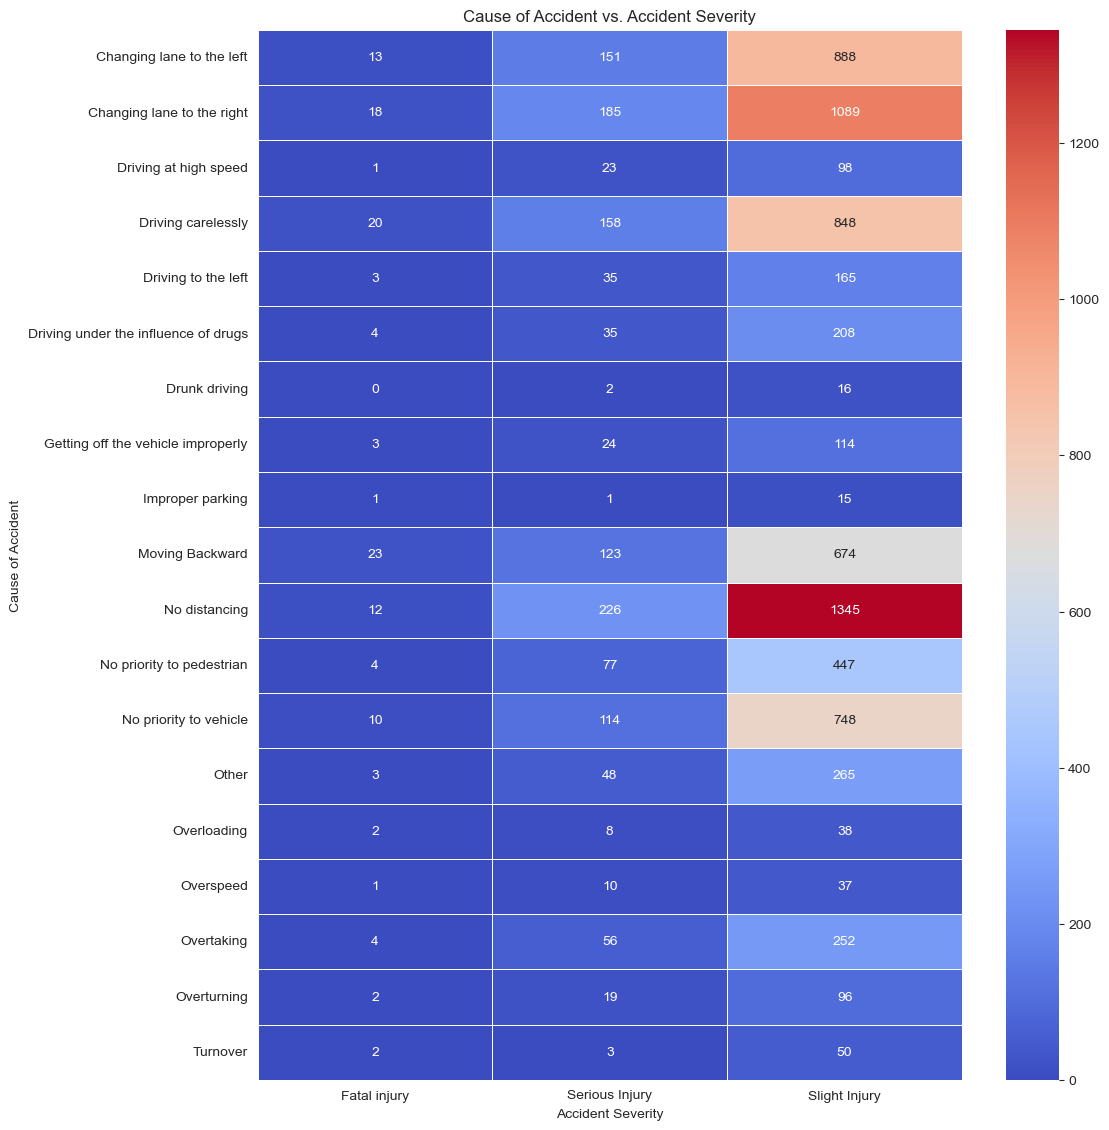

In [28]:
plt.figure(figsize=(25,30))
sns.set_style("whitegrid")
plt.subplot(2, 2, 3)
cause_severity = pd.crosstab(df["Cause_of_accident"], df["Accident_severity"])
sns.heatmap(cause_severity, cmap="coolwarm", annot=True, fmt="d", linewidths=0.5)
plt.title("Cause of Accident vs. Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Cause of Accident")


In [29]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['Accident_severity'])

In [30]:
Y = df['Accident_severity']                
X = df.drop(columns=['Accident_severity']) 

In [31]:
categorical_cols = X.select_dtypes(include='object').columns
print("Categorical columns to encode:", list(categorical_cols))

Categorical columns to encode: ['Time', 'Day_of_week', 'Age_band_of_driver', 'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured', 'Weather_conditions', 'Cause_of_accident']


In [32]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42)

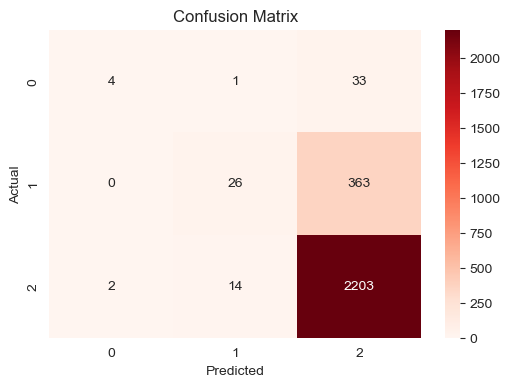

In [34]:
model = RandomForestClassifier()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=np.unique(Y_test), yticklabels=np.unique(Y_test))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
dt_model = DecisionTreeClassifier(random_state=42)

In [36]:
dt_model.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

In [37]:
estimated_acc = dt_model.score(X_test, Y_test)
print(f"Decision Tree Estimated Accuracy: {estimated_acc:.4f}")

Decision Tree Estimated Accuracy: 0.7925


In [38]:
rf_model = RandomForestClassifier(random_state=42)

In [39]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [40]:
estimated_acc2 = rf_model.score(X_test, Y_test)
print(f"random forest Estimated Accuracy: {estimated_acc2:.4f}")

random forest Estimated Accuracy: 0.8458


In [41]:
xgb=XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
xgb.fit(X_train, Y_train)

/Users/rahafa/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [14:37:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [42]:
estimated_acc3 = xgb.score(X_test, Y_test)
print(f"Xgb Estimated Accuracy: {estimated_acc3:.4f}")

Xgb Estimated Accuracy: 0.8420


In [43]:
cat_model = CatBoostClassifier(verbose=0, random_state=42)

In [44]:
cat_model.fit(X_train, Y_train)

In [45]:
estimated_acc4 = cat_model.score(X_test, Y_test)
print(f"catboost Estimated Accuracy: {estimated_acc4:.4f}")

catboost Estimated Accuracy: 0.8409


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import pandas as pd
from sklearn.metrics import RocCurveDisplay, roc_auc_score



 





models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    "CatBoost": CatBoostClassifier(verbose=0)
}


for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{name} (Default Parameters):")
    print("Accuracy:", accuracy_score(Y_test, y_pred))
    print("Precision:", precision_score(Y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(Y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(Y_test, y_pred, average='weighted'))
    print("Classification Report:\n", classification_report(Y_test, y_pred))




Random Forest (Default Parameters):
Accuracy: 0.8420256991685563
Precision: 0.8036950472721409
Recall: 0.8420256991685563
F1 Score: 0.7850327672489522
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.11      0.19        38
           1       0.56      0.06      0.11       389
           2       0.85      0.99      0.91      2219

    accuracy                           0.84      2646
   macro avg       0.73      0.39      0.40      2646
weighted avg       0.80      0.84      0.79      2646


Decision Tree (Default Parameters):
Accuracy: 0.7917611489040061
Precision: 0.7768962664137842
Recall: 0.7917611489040061
F1 Score: 0.7837376194399092
Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.34      0.36        38
           1       0.31      0.26      0.28       389
           2       0.86      0.89      0.88      2219

    accuracy                           0.79      

/Users/rahafa/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [14:40:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost (Default Parameters):
Accuracy: 0.8420256991685563
Precision: 0.8018874485495031
Recall: 0.8420256991685563
F1 Score: 0.785214598103719
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.11      0.17        38
           1       0.57      0.06      0.11       389
           2       0.85      0.99      0.91      2219

    accuracy                           0.84      2646
   macro avg       0.64      0.39      0.40      2646
weighted avg       0.80      0.84      0.79      2646


CatBoost (Default Parameters):
Accuracy: 0.8408919123204838
Precision: 0.8124888231358643
Recall: 0.8408919123204838
F1 Score: 0.773967685367357
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.03      0.05        38
           1       0.62      0.03      0.05       389
           2       0.84      1.00      0.91      2219

    accuracy                           0.84      2646
   macro

C:\Users\r2582\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [11:26:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


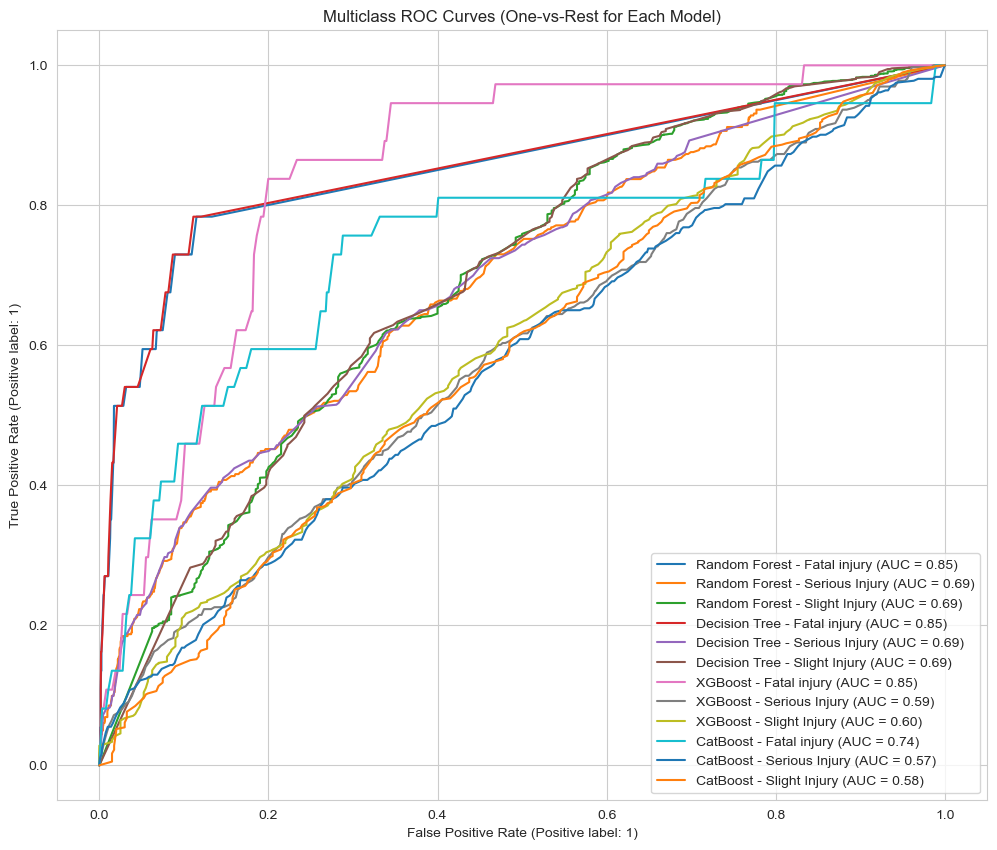

In [53]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt


n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))


best_models = {
    "Random Forest": rf_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
    "CatBoost": cat_grid.best_estimator_
}


plt.figure(figsize=(12, 10))

for name, model in best_models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)

    for i in range(n_classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            y_proba[:, i],
            name=f"{name} - {le.classes_[i]}",
            ax=plt.gca()
        )

plt.title("Multiclass ROC Curves (One-vs-Rest for Each Model)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



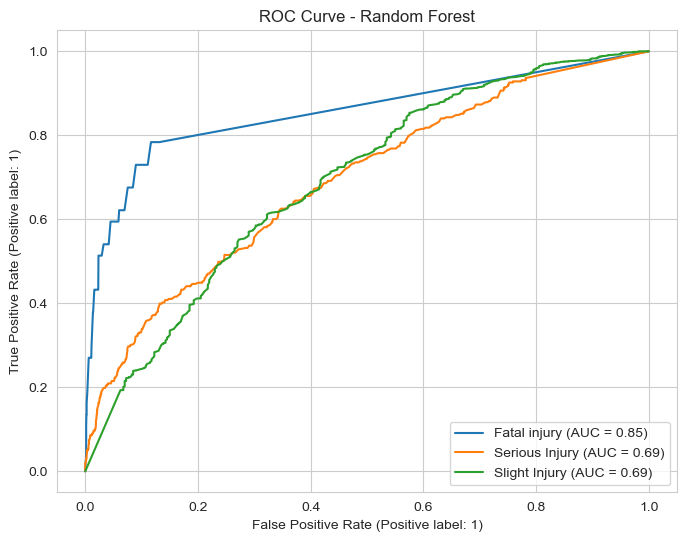

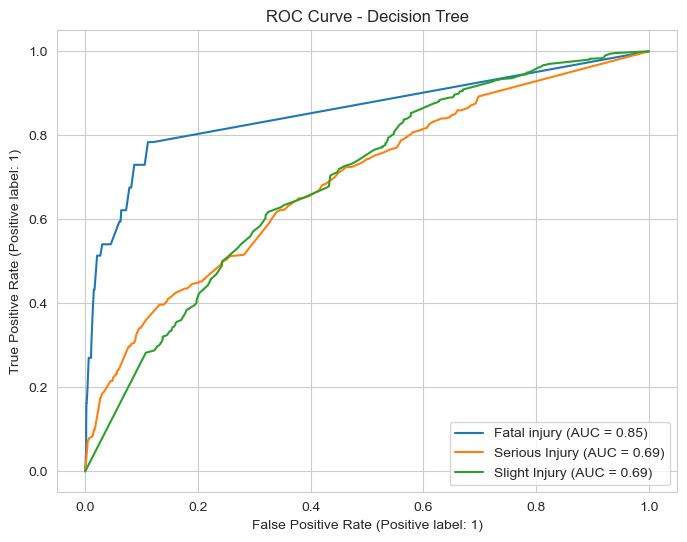

C:\Users\r2582\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [11:26:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


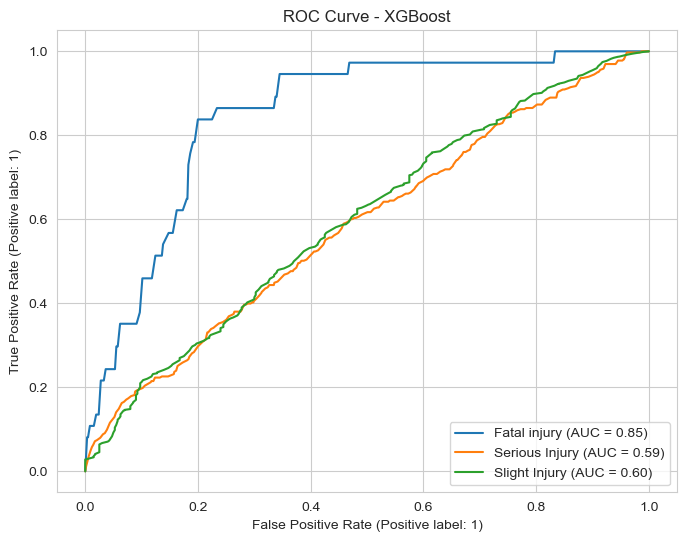

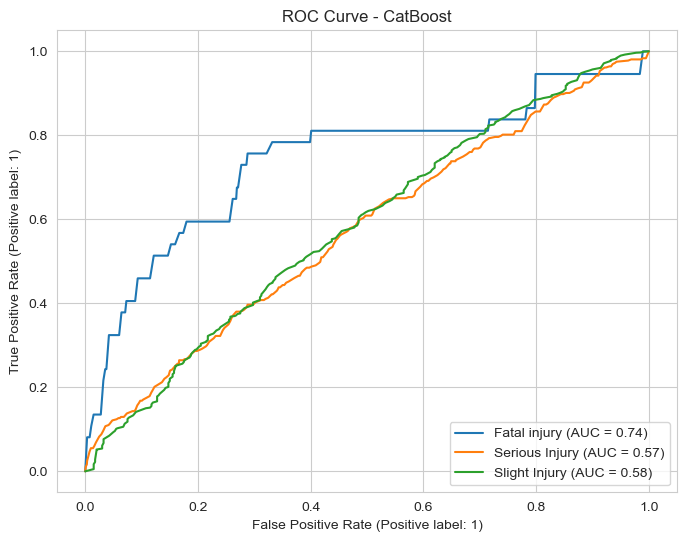

In [52]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt


n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))


best_models = {
    "Random Forest": rf_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
    "CatBoost": cat_grid.best_estimator_
}


for name, model in best_models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            y_proba[:, i],
            name=f"{le.classes_[i]}",
            ax=plt.gca()
        )
    plt.title(f"ROC Curve - {name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


In [50]:
from sklearn.model_selection import GridSearchCV

# Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}
rf_grid = GridSearchCV(RandomForestClassifier(), rf_param_grid, cv=5, scoring='f1_weighted')
rf_grid.fit(X_train, Y_train)
print("Best Random Forest Parameters:", rf_grid.best_params_)

# Decision Tree
dt_param_grid = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5, scoring='f1_weighted')
dt_grid.fit(X_train, Y_train)
print("Best Decision Tree Parameters:", dt_grid.best_params_)

# XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10]
}
xgb_grid = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'), xgb_param_grid, cv=5, scoring='f1_weighted')
xgb_grid.fit(X_train, Y_train)
print("Best XGBoost Parameters:", xgb_grid.best_params_)

# CatBoost
cat_param_grid = {
    'depth': [4, 6, 8],
    'iterations': [100, 200]
}
cat_grid = GridSearchCV(CatBoostClassifier(verbose=0), cat_param_grid, cv=5, scoring='f1_weighted')
cat_grid.fit(X_train, Y_train)
print("Best CatBoost Parameters:", cat_grid.best_params_)



Best Random Forest Parameters: {'max_depth': None, 'n_estimators': 100}
Best Decision Tree Parameters: {'max_depth': None, 'min_samples_split': 2}


/Users/rahafa/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [14:43:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/rahafa/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [14:43:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/rahafa/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [14:43:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/rahafa/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [14:43:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not use

Best XGBoost Parameters: {'max_depth': 10, 'n_estimators': 200}
Best CatBoost Parameters: {'depth': 8, 'iterations': 200}


In [51]:
rf_model2 = RandomForestClassifier(max_depth=None, n_estimators=100, random_state=42)
rf_model2.fit(X_train, Y_train)


RandomForestClassifier(random_state=42)

In [67]:
y_pred2 = rf_model2.predict(X_test)
y_pred_trainrf = rf_model2.predict(X_train)
print("Evaluation with Best Parameters:")
print(classification_report(Y_test, y_pred2))

Evaluation with Best Parameters:
              precision    recall  f1-score   support

           0       0.83      0.13      0.23        38
           1       0.66      0.07      0.13       389
           2       0.85      0.99      0.92      2219

    accuracy                           0.85      2646
   macro avg       0.78      0.40      0.43      2646
weighted avg       0.82      0.85      0.79      2646



In [68]:
print("train accuracy {}".format(accuracy_score(Y_train,y_pred_trainrf)))
print("test accuracy {}".format(accuracy_score(Y_test,y_pred2)))


train accuracy 0.9998379517096094
test accuracy 0.8458049886621315


In [53]:
dt_model2= DecisionTreeClassifier(max_depth=None, min_samples_split=2, random_state=42)
dt_model2.fit(X_train, Y_train)


DecisionTreeClassifier(random_state=42)

In [60]:
y_pred_dt2 = dt_model2.predict(X_test)
y_pred_train = dt_model2.predict(X_train)
print("Decision Tree Evaluation with Best Parameters:")
print(classification_report(Y_test, y_pred_dt2))


Decision Tree Evaluation with Best Parameters:
              precision    recall  f1-score   support

           0       0.39      0.34      0.37        38
           1       0.32      0.27      0.29       389
           2       0.87      0.89      0.88      2219

    accuracy                           0.79      2646
   macro avg       0.53      0.50      0.51      2646
weighted avg       0.78      0.79      0.79      2646



In [62]:
print("train accuracy {}".format(accuracy_score(Y_train,y_pred_train)))
print("test accuracy {}".format(accuracy_score(Y_test,y_pred_dt2)))


train accuracy 0.9998379517096094
test accuracy 0.7925170068027211


In [55]:
xgb_best2= XGBClassifier(max_depth=10, n_estimators=200, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_best2.fit(X_train, Y_train)

/Users/rahafa/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [14:49:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [63]:
y_pred_xgb = xgb_best2.predict(X_test)
y_pred_trainxgb = xgb_best2.predict(X_train)
print("XGBoost Evaluation with Best Parameters:")
print(classification_report(Y_test, y_pred_xgb))

XGBoost Evaluation with Best Parameters:
              precision    recall  f1-score   support

           0       0.23      0.08      0.12        38
           1       0.48      0.11      0.18       389
           2       0.85      0.98      0.91      2219

    accuracy                           0.84      2646
   macro avg       0.52      0.39      0.40      2646
weighted avg       0.79      0.84      0.79      2646



In [64]:
print("train accuracy {}".format(accuracy_score(Y_train,y_pred_trainxgb)))
print("test accuracy {}".format(accuracy_score(Y_test,y_pred_xgb)))

train accuracy 0.9319397180359748
test accuracy 0.8374905517762661


In [58]:
cat_model2 = CatBoostClassifier(depth=8, iterations=200, verbose=0, random_state=42)
cat_model2.fit(X_train, Y_train)

In [65]:
y_pred_cat2 = cat_model2.predict(X_test)
y_pred_traincat = cat_model2.predict(X_train)
print("CatBoost Evaluation with Best Parameters:")
print(classification_report(Y_test, y_pred_cat2))

CatBoost Evaluation with Best Parameters:
              precision    recall  f1-score   support

           0       1.00      0.03      0.05        38
           1       0.50      0.03      0.05       389
           2       0.84      1.00      0.91      2219

    accuracy                           0.84      2646
   macro avg       0.78      0.35      0.34      2646
weighted avg       0.79      0.84      0.77      2646



In [66]:
print("train accuracy {}".format(accuracy_score(Y_train,y_pred_traincat)))
print("test accuracy {}".format(accuracy_score(Y_test,y_pred_cat2)))

train accuracy 0.857721601037109
test accuracy 0.8393801965230536
